<a href="https://colab.research.google.com/github/aayurganesh2007-max/Neural_Networks_with_pytorch/blob/main/Sample_model_training.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Text(0.5, 0, 'Epochs')

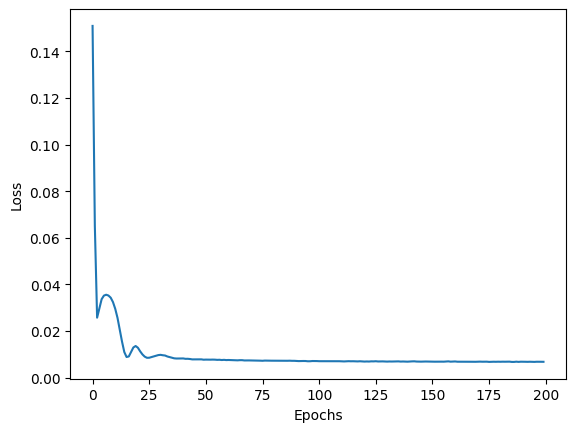

In [50]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from sklearn.model_selection import train_test_split

#Feature engineering the datasets and creating the arrays to pass to the tensor of pytorch

url = 'https://raw.githubusercontent.com/aayurganesh2007-max/Neural_Networks_with_pytorch/refs/heads/main/student_dataset_10000_rows.csv'
total_df = pd.read_csv(url)

main_df = total_df.drop(["placement_status", "internet_usage"],axis =1)

x = main_df.drop("exam_score",axis=1)
y = main_df["exam_score"]/100.0

#Normalising the features using z-score scaling
x_normalised = (x - x.mean())/x.std()

#Converting the data to numpy arrays and splitting the data
x_np = x_normalised.to_numpy()
y_np = y.to_numpy()


x_train, x_test, y_train, y_test = train_test_split(x_np, y_np, test_size=0.2, random_state=42)
x_train = torch.FloatTensor(x_train)
x_test = torch.FloatTensor(x_test)
y_train = torch.FloatTensor(y_train)
y_test = torch.FloatTensor(y_test)

#Creating the basic class for the neural network


class Model(nn.Module):

  def __init__(self,in_features = 5, h1 = 128, h2 = 64 , h3 = 32, out_features = 1, p = 0.05):
    super().__init__()
    self.fc1 = nn.Linear(in_features,h1)
    self.fc2 = nn.Linear(h1,h2)
    self.fc3 = nn.Linear(h2,h3)
    self.out = nn.Linear(h3,out_features)
    self.dropout = nn.Dropout(p)

  def forward(self,x):
    x = F.relu(self.fc1(x))
    x = self.dropout(x)
    x = F.relu(self.fc2(x))
    x = self.dropout(x)
    x = F.relu(self.fc3(x))
    x = self.dropout(x)
    x = torch.sigmoid(self.out(x))
    return x

torch.manual_seed(41)
model = Model()

#Setting the loss function
loss_function = nn.MSELoss()
#Set the learning rate
learning_rate = 0.01
#Choose the gradient descent
optimiser = torch.optim.Adam(model.parameters(),lr = learning_rate)

#Training the model
epochs = 200
losses = []

for i in range(epochs):
  #Go forward and make the predictions
  y_pred = model(x_train)
  #Calculate the loss
  loss = loss_function(y_pred.squeeze(),y_train)
  losses.append(loss.item())

  #Backpropogation
  optimiser.zero_grad()
  loss.backward()
  optimiser.step()

#Plotting the loss function
plt.plot(range(epochs),losses)
plt.ylabel('Loss')
plt.xlabel('Epochs')






In [56]:
import torch.nn as nn

# Use a different variable name to avoid potential conflicts with a corrupted global 'loss_function'
eval_loss_function = nn.MSELoss()

model.eval()
with torch.no_grad():
  y_eval = model.forward(x_test)
  y_test_pred = y_eval.squeeze()
  loss = eval_loss_function(y_test_pred,y_test) # Use the new variable
print(loss)

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
y_test = y_test.numpy()*100
y_test_pred = y_test_pred.numpy()*100
mae = mean_absolute_error(y_test, y_test_pred)
mse = mean_squared_error(y_test, y_test_pred)
r2 = r2_score(y_test, y_test_pred)

print("Mean Absolute Error:", mae)
print("Mean Squared Error:", mse)
print("R-squared:", r2)

# create a scatter plot for the actual values and predictions with blue color for prediction and red for the actual
plt.scatter(y_test, y_test_pred, color='blue', label='Prediction')
plt.scatter(y_test, y_test, color='red', label='Actual')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.legend()
plt.show()


TypeError: 'int' object is not callable